# **Medical Image Classification: Logistic Regression & K-Nearest Neighbors (kNN)**

An Applied Machine Learning research project exploring classification algorithms for breast ultrasound images.

---

### **Context & Dataset: BreastMNIST**

The objective of this project is to classify breast ultrasound images into two distinct categories: **Cancer** (negative class, label 0) and **Normal** (positive class, label 1).

We utilize the **BreastMNIST** dataset from the MedMNIST collection, which consists of 780 grayscale images, each with a resolution of 28x28 pixels. The dataset is already pre-divided into training, validation, and test sets. We evaluate the performance of Logistic Regression (with and without regularization and class balancing) alongside a non-parametric K-Nearest Neighbors (kNN) classifier.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torchvision.transforms as transforms
import medmnist
from medmnist import INFO, Evaluator
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.neighbors import KNeighborsClassifier

import warnings
warnings.filterwarnings('ignore')

## 1. Data Acquisition and Preprocessing

The dataset is fetched using the MedMNIST API. The images are loaded as numpy arrays.

In [3]:
data_flag = 'breastmnist'
download = True

info = INFO[data_flag]
DataClass = getattr(medmnist, info['python_class'])

# Preprocessing pipeline provided by MedMNIST
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])

# Load datasets
train_dataset = DataClass(split='train', transform=data_transform, download=download)
val_dataset = DataClass(split='val', transform=data_transform, download=download)
test_dataset = DataClass(split='test', transform=data_transform, download=download)

# Extract images and labels
img_train, labels_train = train_dataset.imgs, train_dataset.labels
img_val, labels_val = val_dataset.imgs, val_dataset.labels
img_test, labels_test = test_dataset.imgs, test_dataset.labels

print(f"Training images shape: {img_train.shape}")
print(f"Validation images shape: {img_val.shape}")
print(f"Test images shape: {img_test.shape}")

100%|██████████| 560k/560k [00:01<00:00, 503kB/s]  

Training images shape: (546, 28, 28)
Validation images shape: (78, 28, 28)
Test images shape: (156, 28, 28)


### Class Imbalance Analysis

Before training, it is crucial to analyze the class distribution across the dataset to determine if class-weighting strategies are necessary.

In [4]:
# Absolute frequency
labels_dict = {
    'Normal (Label 1)': [len(labels_train[labels_train==1]), len(labels_val[labels_val==1]), len(labels_test[labels_test==1])],
    'Cancer (Label 0)': [len(labels_train[labels_train==0]), len(labels_val[labels_val==0]), len(labels_test[labels_test==0])]
}
df_abs = pd.DataFrame(data=labels_dict, index=['Train Set', 'Validation Set', 'Test Set'])
display(df_abs)

# Relative frequency (%)
df_rel = pd.DataFrame(index=df_abs.index, columns=['Normal (%)', 'Cancer (%)'])
df_rel.iloc[0,:] = df_abs.iloc[0,:] / len(labels_train) * 100
df_rel.iloc[1,:] = df_abs.iloc[1,:] / len(labels_val) * 100
df_rel.iloc[2,:] = df_abs.iloc[2,:] / len(labels_test) * 100
display(df_rel.round(2))

,Normal (Label 1),Cancer (Label 0)
Train Set,399,147
Validation Set,57,21
Test Set,114,42


,Normal (%),Cancer (%)
Train Set,73.076923,26.923077
Validation Set,73.076923,26.923077
Test Set,73.076923,26.923077


### Feature Vectorization

Since classical models like Logistic Regression and kNN expect 1D arrays, we flatten the $28 \times 28$ matrices into vectors of $784$ features. Additionally, pixel values are min-max scaled by dividing by $255.0$.

In [5]:
x_train = img_train.reshape(img_train.shape[0], -1) / 255.0
x_val = img_val.reshape(img_val.shape[0], -1) / 255.0
x_test = img_test.reshape(img_test.shape[0], -1) / 255.0

y_train = labels_train.flatten()
y_val = labels_val.flatten()
y_test = labels_test.flatten()

print(f"Flattened Training Set: {x_train.shape}")

Flattened Training Set: (546, 784)


## 2. Logistic Regression

### Baseline Model (No Regularization)
We begin with a standard, unregularized Logistic Regression model optimized using Stochastic Average Gradient descent (SAG).

In [6]:
lr_baseline = LogisticRegression(penalty=None, solver='sag', max_iter=10000)
lr_baseline.fit(x_train, y_train)

print(f'Train Accuracy: {lr_baseline.score(x_train, y_train):.4f}')
print(f'Test Accuracy: {lr_baseline.score(x_test, y_test):.4f}')

predictions_baseline = lr_baseline.predict(x_test)
print(f'F1-Score: {metrics.f1_score(y_test, predictions_baseline):.4f}')
print(f'Balanced Accuracy: {metrics.balanced_accuracy_score(y_test, predictions_baseline):.4f}')

Train Accuracy: 1.0000
Test Accuracy: 0.7564
F1-Score: 0.8348
Balanced Accuracy: 0.6830


### L2 Regularization & Hyperparameter Search

To mitigate potential overfitting in the high-dimensional feature space, L2 regularization (Ridge) is applied. We perform a logarithmic grid search to find the optimal inverse-regularization strength (`C`) using the validation set.

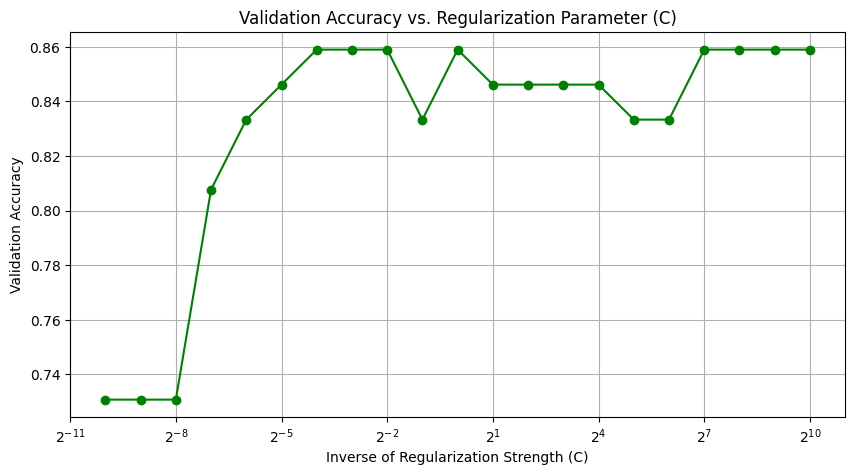

Maximum Validation Accuracy: 0.8590
Optimal C parameter: 0.0625


In [17]:
scores_l2 = []
coefs_l2 = []

# Logarithmic search space for C
for i in range(-10, 11):
    C_val = 2**i
    lr_reg = LogisticRegression(penalty='l2', solver='sag', max_iter=10000, C=C_val)
    lr_reg.fit(x_train, y_train)
    scores_l2.append(lr_reg.score(x_val, y_val))
    coefs_l2.append(C_val)

plt.figure(figsize=(10, 5))
plt.plot(coefs_l2, scores_l2, marker='o', color='g')
plt.xscale('log', base=2)
plt.title('Validation Accuracy vs. Regularization Parameter (C)')
plt.xlabel('Inverse of Regularization Strength (C)')
plt.ylabel('Validation Accuracy')
plt.grid(True)
plt.show()

best_C = coefs_l2[np.argmax(scores_l2)]
print(f'Maximum Validation Accuracy: {max(scores_l2):.4f}')
print(f'Optimal C parameter: {best_C}')

Evaluating the optimized, regularized model on the test set:

In [20]:
lr_opt = LogisticRegression(penalty='l2', solver='sag', max_iter=10000, C=best_C)
lr_opt.fit(x_train, y_train)

predictions_opt = lr_opt.predict(x_test)
print(f'Test Accuracy: {lr_opt.score(x_test, y_test):.4f}')
print(f'F1-Score: {metrics.f1_score(y_test, predictions_opt):.4f}')
print(f'Balanced Accuracy: {metrics.balanced_accuracy_score(y_test, predictions_opt):.4f}')

Test Accuracy: 0.7949
F1-Score: 0.8730
Balanced Accuracy: 0.6491


### Addressing Class Imbalance: Weighted Logistic Regression

Observing the slight imbalance in the dataset, we assign inversely proportional class weights (`class_weight='balanced'`) to penalize minority-class misclassifications more heavily. A grid search is performed again focusing on the **Balanced Accuracy** metric.

In [19]:
balanced_scores = []
coefs_bal = []

for i in range(-10, 11):
    C_val = 2**i
    lr_bal = LogisticRegression(penalty='l2', solver='sag', max_iter=10000, C=C_val, class_weight='balanced')
    lr_bal.fit(x_train, y_train)
    
    # Using Balanced Accuracy for validation selection
    preds_val = lr_bal.predict(x_val)
    balanced_scores.append(metrics.balanced_accuracy_score(y_val, preds_val))
    coefs_bal.append(C_val)

best_C_bal = coefs_bal[np.argmax(balanced_scores)]
print(f'Maximum Validation Balanced Accuracy: {max(balanced_scores):.4f}')
print(f'Optimal C parameter (Balanced): {best_C_bal}')

Maximum Validation Balanced Accuracy: 0.8133
Optimal C parameter (Balanced): 0.5


Final Test Accuracy: 0.7885
Final F1-Score: 0.8493
Final Balanced Accuracy: 0.7650


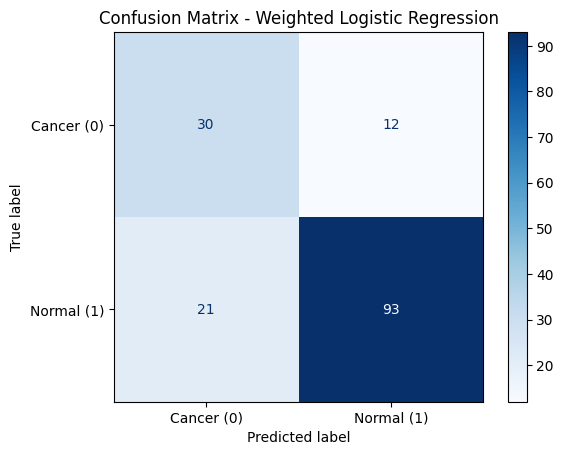

In [10]:
lr_final = LogisticRegression(penalty='l2', solver='sag', max_iter=10000, C=best_C_bal, class_weight='balanced')
lr_final.fit(x_train, y_train)

predictions_final = lr_final.predict(x_test)
print(f'Final Test Accuracy: {lr_final.score(x_test, y_test):.4f}')
print(f'Final F1-Score: {metrics.f1_score(y_test, predictions_final):.4f}')
print(f'Final Balanced Accuracy: {metrics.balanced_accuracy_score(y_test, predictions_final):.4f}')

# Confusion Matrix
cm = metrics.confusion_matrix(y_test, predictions_final, labels=lr_final.classes_)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Cancer (0)', 'Normal (1)'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Weighted Logistic Regression')
plt.show()

### Receiver Operating Characteristic (ROC) Curve

We compare the probabilistic discriminative power of the three Logistic Regression configurations using the ROC curve and the Area Under the Curve (AUC).

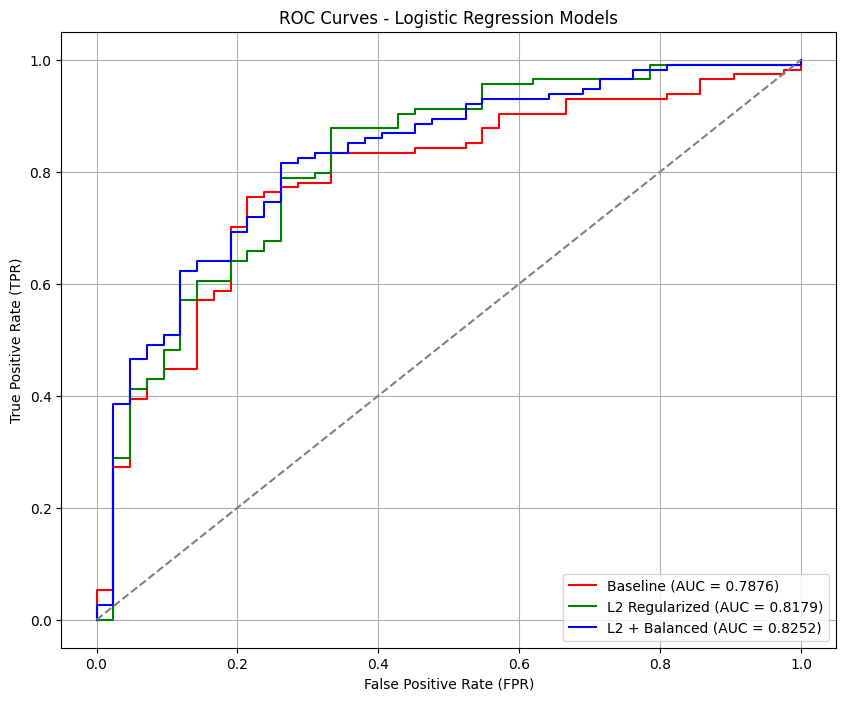

In [11]:
fpr_base, tpr_base, _ = metrics.roc_curve(y_test, lr_baseline.decision_function(x_test))
fpr_opt, tpr_opt, _ = metrics.roc_curve(y_test, lr_opt.decision_function(x_test))
fpr_final, tpr_final, _ = metrics.roc_curve(y_test, lr_final.decision_function(x_test))

auc_base = metrics.roc_auc_score(y_test, lr_baseline.predict_proba(x_test)[:, 1])
auc_opt = metrics.roc_auc_score(y_test, lr_opt.predict_proba(x_test)[:, 1])
auc_final = metrics.roc_auc_score(y_test, lr_final.predict_proba(x_test)[:, 1])

plt.figure(figsize=(10, 8))
plt.plot(fpr_base, tpr_base, color='red', label=f'Baseline (AUC = {auc_base:.4f})')
plt.plot(fpr_opt, tpr_opt, color='green', label=f'L2 Regularized (AUC = {auc_opt:.4f})')
plt.plot(fpr_final, tpr_final, color='blue', label=f'L2 + Balanced (AUC = {auc_final:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('ROC Curves - Logistic Regression Models')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## 3. K-Nearest Neighbors (kNN) Classifier

As a non-parametric alternative, we evaluate the K-Nearest Neighbors algorithm using distance-based weighting. The validation set is employed to determine the optimal neighborhood size ($k$).

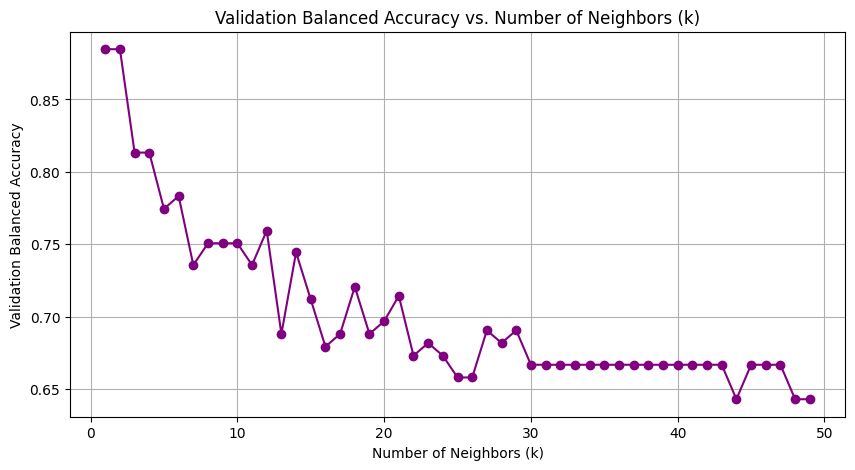

Maximum Validation Balanced Accuracy: 0.8847
Optimal k: 1


In [12]:
knn_scores = []
k_range = range(1, 50)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance')
    knn.fit(x_train, y_train)
    preds_val = knn.predict(x_val)
    knn_scores.append(metrics.balanced_accuracy_score(y_val, preds_val))

plt.figure(figsize=(10, 5))
plt.plot(k_range, knn_scores, marker='o', color='purple')
plt.title('Validation Balanced Accuracy vs. Number of Neighbors (k)')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Validation Balanced Accuracy')
plt.grid(True)
plt.show()

best_k = k_range[np.argmax(knn_scores)]
print(f'Maximum Validation Balanced Accuracy: {max(knn_scores):.4f}')
print(f'Optimal k: {best_k}')

Testing the optimized kNN model:

kNN Test Accuracy: 0.7756
kNN F1-Score: 0.8430
kNN Balanced Accuracy: 0.7337


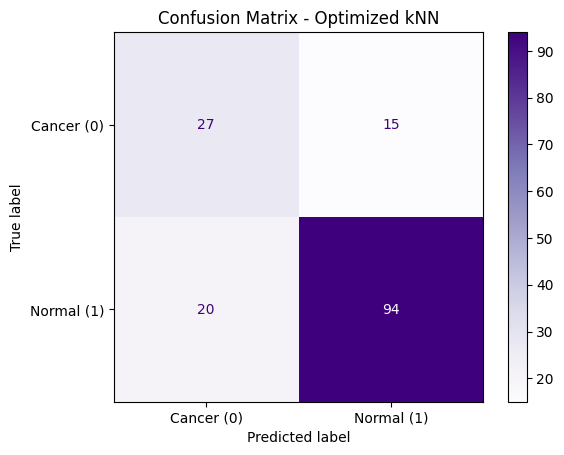

In [13]:
knn_final = KNeighborsClassifier(n_neighbors=best_k, weights='distance')
knn_final.fit(x_train, y_train)

predictions_knn = knn_final.predict(x_test)
print(f'kNN Test Accuracy: {knn_final.score(x_test, y_test):.4f}')
print(f'kNN F1-Score: {metrics.f1_score(y_test, predictions_knn):.4f}')
print(f'kNN Balanced Accuracy: {metrics.balanced_accuracy_score(y_test, predictions_knn):.4f}')

# Confusion Matrix
cm_knn = metrics.confusion_matrix(y_test, predictions_knn, labels=knn_final.classes_)
disp_knn = metrics.ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=['Cancer (0)', 'Normal (1)'])
disp_knn.plot(cmap='Purples')
plt.title('Confusion Matrix - Optimized kNN')
plt.show()